# ***!IMPORTANT NOTICE!***
make sure to run the following commands in terminal before this project can run:
```CMD
pip install sounddevice numpy matplotlib
```
*This was developed with python version* **3.13.xx** check this with:
```CMD
python --version
```
If these do not match unexpected errors may occur but all packages was chosen because the internet agreed on wider stability across different versions of e.g. python.

In [1]:
import sounddevice as sd
import numpy as np
import matplotlib.pyplot as plt

def kick(beats):
    return ("kick", beats)

def snare(beats):
    return ("snare", beats)

def ch(beats):
    return ("ch", beats)

def oh(beats):
    return ("oh", beats)

# Synthesizing a ROLAND TR-707 drum machine
## understanding the ROLAND TR-707 drum machine and thus the project
To understand this project it might be nice to understand what the TR-707 drum machine is and more importantly what it does. The TR-707 drum machine as the name might suggest is a machine that synthesizes the sound of a particular drum set making the TR-707 drum machine sound very iconic and recognizable. Each part of the drum kit weather it being kick, snare, hi-hat closed or open takes in two values they will need to know how often it is sampled and how long it should play.
## Usefulness
This project provides easier access to technology such as the ROLAND TR-707 drum machine which is a physical machine one would have to go out and buy if they can even find one today. *they have become antique*

# Sound
 - ### Analog Domain
Sound is something we perceive with our ears, but physically it is not a tangible object. So what is sound from a scientific perspective? Sound is a mechanical wave that propagates through a medium *such as air* due to vibrations. This can be described mathematically like so in 1D:

$$ \frac{\partial^{2}y(x,t)}{\partial x^{2}} = \frac{1}{c^{2}}\frac{\partial^{2}y(x,t)}{\partial t^{2}} $$
where c is the **propagation speed** measured in **m/s** and given by
$$  c = \sqrt{T/\rho} $$


This equation can model systems such as a vibrating guitar string, where the motion of the string creates sound waves in the surrounding air.

Note that increasing the string tension T or decreasing the string density both increases the propagation speed.

 The displacement *y(x,t)*  depends on both position *x*  and time *t*, meaning the wave evolves over space and time.

 - ### Digital Domain
In the digital domain the sound is limited by the computer architecture, e.g. there is no infinite runtime memory or infinite compute speed this means that the computer needs to approximate the displacement in position *x* and time *t* domain. This can however be solved by sampling, while sampling can be problematic if done too rarely, if done at half the frequency speed then the samples would always show the same value giving a constant value. As explained in, Analog Domain, sound consists of waves and therefore a constant value is not a sound but just a constant voltage send to the speaker. As a rule of thumb the sampling frequency should be twice of the maximum frequency, in the case of this project a sampling frequency of **44100hz** was chosen. *That is the sampling frequency of CD quality*

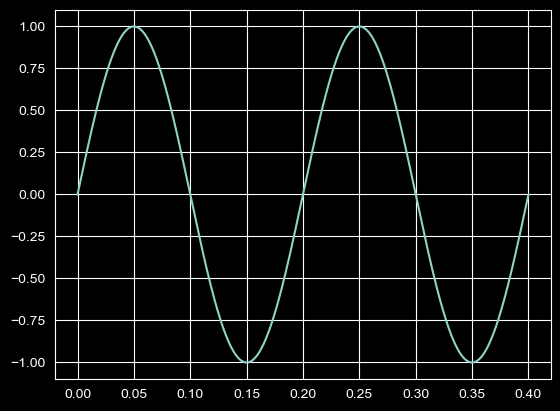

In [5]:
Fs = 44100
t = np.linspace(0, .4, Fs, endpoint=False)
tone = np.sin(2*np.pi*5*t)
plt.plot(t, tone)
plt.show()

## *The following code holds all the sound producing code* ##

### This includes but is not limited to The TR-707: ###
 - kick
 - snare
 - closed hi-hat
 - open hi-hat

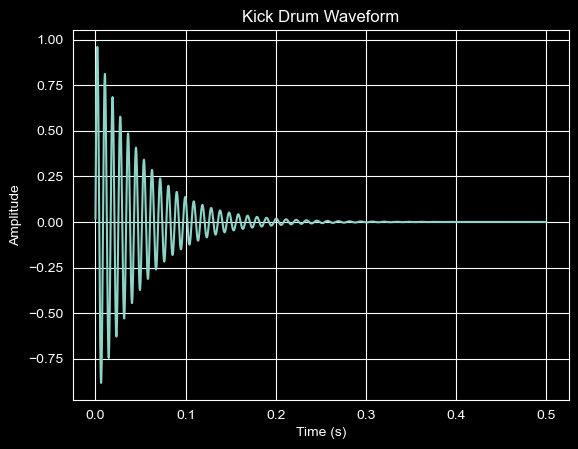

In [6]:
def kick_sound(Fs, duration=1, return_time=False):
    t = np.linspace(0, duration, int(Fs * duration), False)

    # Pitch sweep (classic analog kick)
    f_start = 120
    f_end = 50
    freq = np.linspace(f_start, f_end, len(t))

    phase = 2 * np.pi * np.cumsum(freq) / Fs
    y = np.sin(phase)

    # Fast decay envelope
    envelope = np.exp(-t * 20)
    if return_time:
        return t, y * envelope
    return y * envelope

t_kick, y_kick = kick_sound(Fs,0.5, True)

# Kick plot
plt.figure()
plt.plot(t_kick, y_kick)
plt.title("Kick Drum Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()


# Kick Sound

All sounds in this generated from the same two parameters, Fs being the sampling frequency *44100hz* and then a duration being how many beats should the sound last in a given bar. Meaning if you play:
```python
kick_sound(Fs,0.25)
kick_sound(Fs,0.25)
kick_sound(Fs,0.25)
kick_sound(Fs,0.25)
```
That would be equivalent of a four on the floor beat. There is a little more to making a full kick so let's dive in and see what happens under the surface. First a variable *t* to track the time is calculated. This is gonna be a list of numbers with the timestamps between each sample for the entire duration of the kick sound, excluding the last index since that would be at the exact same time as the first one in the next sound. A typical kick sound sweeps between two frequencies usually from a higher frequency to a lower one. That is mimicked with the exact same math as for calculating *t*. it is just an evenly spaced mapping of differences in the two given frequencies over the duration of the sound meaning in there will be *t* differences in frequency happening over the duration of the kick. and then for that to become sound playable by sound device these frequencies has to be converted to a phase of a sine wave instead of just values moving from 120 to 50 over *t* equal size steps. Envelope is then added to the kick so that it nicely fades out with instant attack, no sustain and an exponential release curve.



In [ ]:
def snare_sound(Fs, duration=1,return_time=False):
    t = np.linspace(0, duration, int(Fs * duration), False)

    # Noise (the "snap")
    noise = np.random.randn(len(t))

    # Tone body
    tone = np.sin(2 * np.pi * 180 * t)

    # Envelope
    envelope = np.exp(-t * 15)
    if return_time:
        return t,(0.7 * noise + 0.3 * tone) * envelope
    return (0.7 * noise + 0.3 * tone) * envelope



In [ ]:
def hihat_closed(Fs, duration=1,return_time=False):
    t = np.linspace(0, duration, int(Fs * duration), False)

    noise = np.random.randn(len(t))

    envelope = np.exp(-t * 80)
    if return_time:
        return t,noise * envelope
    return noise * envelope

In [ ]:
def highpass(signal, alpha=0.9):
    y = np.zeros_like(signal)
    for i in range(1, len(signal)):
        y[i] = alpha * (y[i-1] + signal[i] - signal[i-1])
    return y

In [ ]:
def hihat_open(Fs, duration=1,return_time=False):
    t = np.linspace(0, duration, int(Fs * duration), False)

    # Metallic partials (more inharmonic, bell-like)
    freqs = [500, 900, 1400, 2200, 2800]  # inharmonic ratios
    metallic = sum(np.sin(2 * np.pi * f * t) for f in freqs)

    # Exponential decay (faster for higher freqs)
    decay = np.exp(-t * 20)
    metallic *= decay

    # White noise tail
    noise = np.random.randn(len(t))
    noise_env = np.exp(-t * 12)
    noise = noise * noise_env

    # Mix metallic + noise
    y = 0.6 * metallic + 0.4 * noise

    # high-pass for brightness (sharp attack)
    y = highpass(y, alpha=0.73)

    # Soft clipping for grit
    y = np.tanh(y * 3.0)

    # Normalize
    y /= np.max(np.abs(y) + 1e-8)

    if return_time:
        return t,y
    return y

In [ ]:
def build_beat(events, Fs, seconds_per_beat):
    total_beats = sum(beats for _, beats in events)
    total_samples = int(total_beats * seconds_per_beat * Fs)

    output = np.zeros(total_samples)
    cursor = 0

    for drum, beats in events:
        duration = beats * seconds_per_beat
        samples = int(duration * Fs)

        if drum == "kick":
            y = kick_sound(Fs, duration)
        elif drum == "snare":
            y = snare_sound(Fs, duration)
        elif drum == "ch":
            y = hihat_closed(Fs, duration)
        elif drum == "oh":
            y = hihat_open(Fs, duration)
        else:
            y = np.zeros(samples)

        output[cursor:cursor+samples] += y[:samples]
        cursor += samples
    return output

beat = [
    kick(0.25), ch(0.25), ch(0.25), ch(0.25),
    snare(0.5), ch(0.5),
    kick(0.5), ch(0.25), ch(0.25),
    snare(0.5), ch(0.25), ch(0.25),

    kick(0.25), ch(0.25), ch(0.25), ch(0.25),
    snare(0.5), ch(0.5),
    kick(0.5), ch(0.25), ch(0.25),
    snare(0.5), ch(0.25), ch(0.25),

    kick(0.25), ch(0.25), ch(0.25), ch(0.25),
    snare(0.5), ch(0.5),
    kick(0.5), ch(0.25), ch(0.25),
    snare(0.5), ch(0.25), ch(0.25),

    kick(0.25), ch(0.25), ch(0.25), ch(0.25),
    snare(0.5), ch(0.5),
    kick(0.5), ch(0.25), ch(0.25),
    snare(0.5), ch(0.25), ch(0.25),

    kick(0.25), ch(0.25), ch(0.25), ch(0.25),
    snare(0.5), ch(0.5),
    kick(0.5), ch(0.25), ch(0.25),
    snare(0.5), ch(0.25), ch(0.25),

    kick(0.25), ch(0.25), ch(0.25), ch(0.25),
    snare(0.5), ch(0.5),
    kick(0.5), ch(0.25), ch(0.25),
    snare(0.5), ch(0.25), ch(0.25),

    kick(0.25), ch(0.25), ch(0.25), ch(0.25),
    snare(0.5), ch(0.5),
    kick(0.5), ch(0.25), ch(0.25),
    snare(0.5), ch(0.25), ch(0.25),

    kick(0.25), ch(0.25), ch(0.25), ch(0.25),
    snare(0.5), ch(0.5),
    kick(0.5), ch(0.25), ch(0.25),
    snare(0.5), ch(0.25), ch(0.25)
]

bpm = 140
seconds_per_beat = 60 / bpm
Fs = 44100

output = build_beat(beat, Fs, seconds_per_beat)
output /= np.max(np.abs(output))
output = output.reshape(-1,1)
print("Just trust me bro, i am playing sound!")
sd.play(output, Fs)
sd.wait()

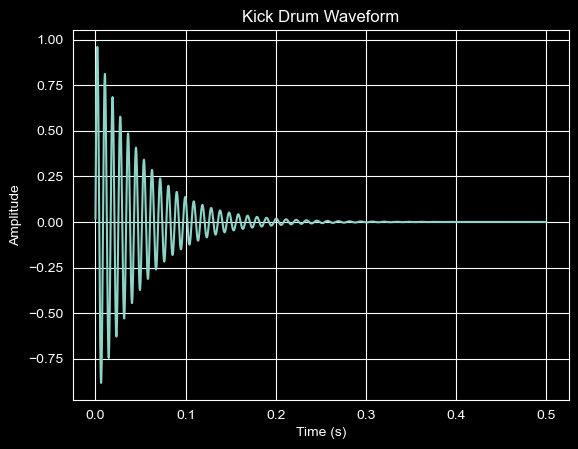

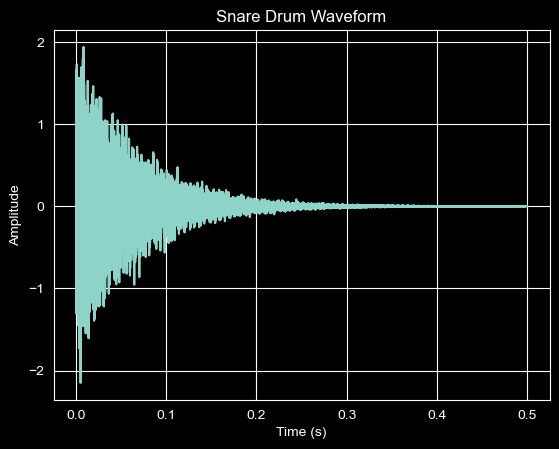

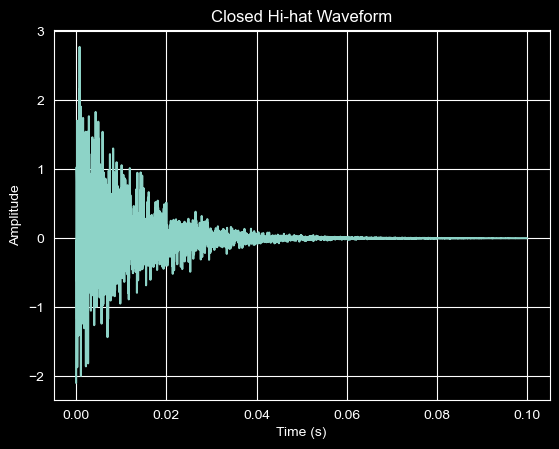

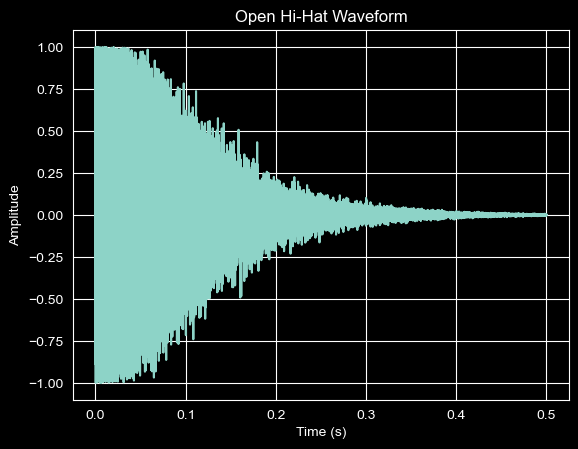

In [4]:
# Generate sounds
t_snare, y_snare = snare_sound(Fs,0.5, True)
t_hat, y_hat = hihat_closed(Fs,0.1, True)
t_oh, y_oh = hihat_open(Fs,0.5, True)


# Snare plot
plt.figure()
plt.plot(t_snare, y_snare)
plt.title("Snare Drum Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# CH plot
plt.figure()
plt.plot(t_hat, y_hat)
plt.title("Closed Hi-hat Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# OH plot
plt.figure()
plt.plot(t_oh, y_oh)
plt.title("Open Hi-Hat Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()